In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset parameters
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

K_PROBES = 4
EPSILON = 0.1

# Device setup for CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

class MNISTClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        # ResNet18 backbone
        resnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False)
        self.intro = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool
        )
        self.layer1 = resnet_model.layer1
        self.layer2 = resnet_model.layer2
        self.layer3 = resnet_model.layer3
        self.layer4 = resnet_model.layer4
        self.averagepool = resnet_model.avgpool

        # Classification head (512 + O0/O1/O2 + 4 fisher terms = 519)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 3 + 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        # Compute energy as mean of representation
        energy = x.mean()

        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True
        )[0]

        grads_flat = grads.view(grads.size(0), -1)

        # Use only first 2 dimensions or project to 2D space
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def compute_local_fisher(self, x):
        scores = self.compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        # Convert 1-channel to 3-channel (RGB) by repeating
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)  # [batch, 3, 28, 28]

        # Resize to ResNet input size (224x224)
        x_resized = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        with torch.set_grad_enabled(True):
            if not x_resized.requires_grad:
                x_resized.requires_grad_(True)

            # Compute derivatives with respect to input
            O0 = self.compute_local_fisher(x_resized)

            # For image tensors, use small Gaussian perturbations instead of probe directions
            perturbation = torch.randn_like(x_resized) * self.epsilon
            x_pos = x_resized + perturbation
            x_neg = x_resized - perturbation

            I_pos = self.compute_local_fisher(x_pos)
            I_neg = self.compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        # Forward through ResNet
        h = self.intro(x_resized)

        # Apply layers and compute Fisher at each stage
        h = self.layer1(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer1 = self.compute_local_fisher(h)

        h = self.layer2(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer2 = self.compute_local_fisher(h)

        h = self.layer3(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer3 = self.compute_local_fisher(h)

        h = self.layer4(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer4 = self.compute_local_fisher(h)

        # Global average pool
        h_pooled = self.averagepool(h)
        h_flat = h_pooled.flatten(1)

        # Concatenate all features
        fish_concat = torch.cat([fish_layer1, fish_layer2, fish_layer3, fish_layer4], dim=1)
        features = torch.cat([h_flat, O0, O1, O2, fish_concat], dim=1)

        # Classify
        logits = self.classifier(features)
        return logits

def run_experiment(model, opt):
    model = model.to(device)
    optimizer = opt
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet18_fisher_adam, test_accuracies_resnet18_fisher_adam = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet18_fisher_sgd, test_accuracies_resnet18_fisher_sgd = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet18_fisher_rmsprop, test_accuracies_resnet18_fisher_rmsprop = run_experiment(model, opt)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet18_fisher_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet18_fisher_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet18_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet18_fisher_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet18_fisher_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet18_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet18_Fisher Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet18_Fisher Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet18_fisher_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet18_fisher_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000


Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


KeyboardInterrupt: 

Using device: cuda
Train samples: 60000, Test samples: 10000
Starting Training for 10 epochs...
Epoch 0, Batch 0/938: Loss=2.6082
Epoch 0, Batch 150/938: Loss=0.1573
Epoch 0, Batch 300/938: Loss=0.0610
Epoch 0, Batch 450/938: Loss=0.0553
Epoch 0, Batch 600/938: Loss=0.0073
Epoch 0, Batch 750/938: Loss=0.0844
Epoch 0, Batch 900/938: Loss=0.0050
Epoch 0 | Train Loss: 0.1341 | Test Accuracy: 98.00%
Epoch 1, Batch 0/938: Loss=0.0259
Epoch 1, Batch 150/938: Loss=0.0183
Epoch 1, Batch 300/938: Loss=0.0325
Epoch 1, Batch 450/938: Loss=0.1370
Epoch 1, Batch 600/938: Loss=0.1308
Epoch 1, Batch 750/938: Loss=0.0848
Epoch 1, Batch 900/938: Loss=0.0023
Epoch 1 | Train Loss: 0.0600 | Test Accuracy: 98.60%
Epoch 2, Batch 0/938: Loss=0.0924
Epoch 2, Batch 150/938: Loss=0.1751
Epoch 2, Batch 300/938: Loss=0.1972
Epoch 2, Batch 450/938: Loss=0.0056
Epoch 2, Batch 600/938: Loss=0.0234
Epoch 2, Batch 750/938: Loss=0.0044
Epoch 2, Batch 900/938: Loss=0.0666
Epoch 2 | Train Loss: 0.0453 | Test Accuracy: 98

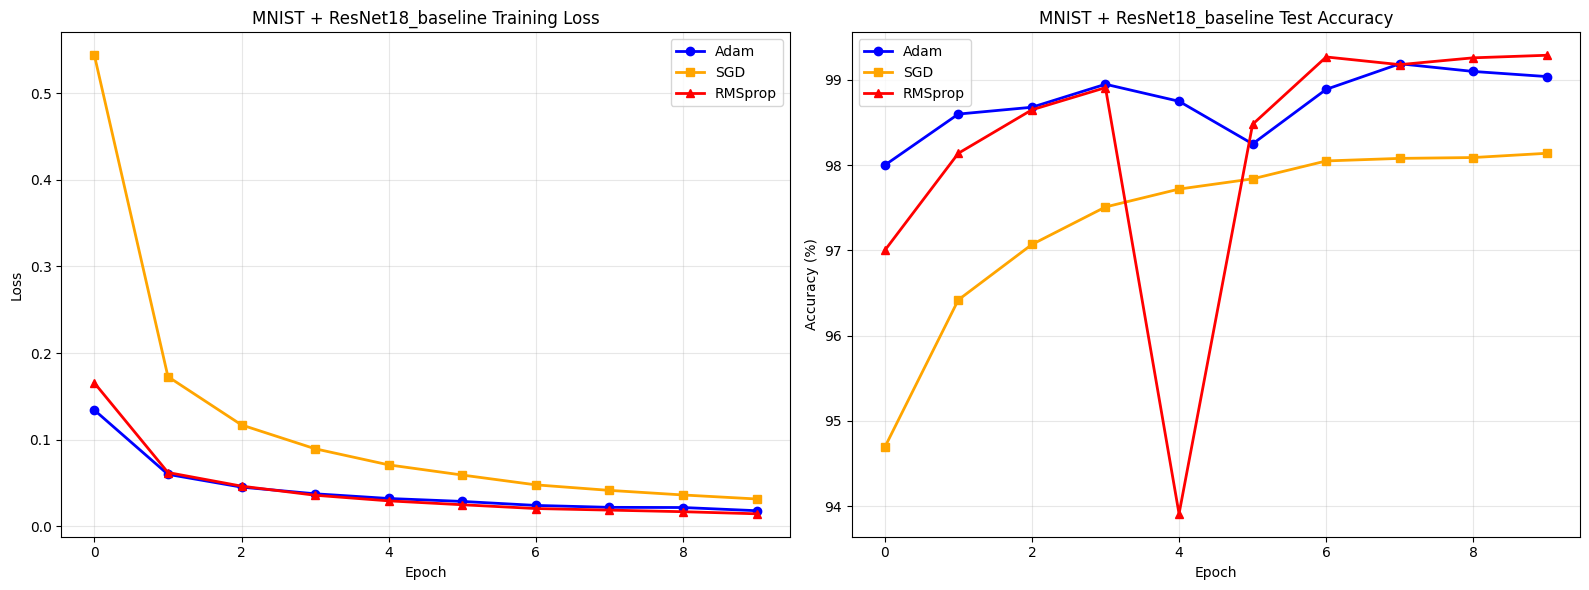

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

# Download and prepare MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

print("Downloading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Download ResNet18 (not pretrained)
print("Downloading ResNet18 model...")
base_resnet18 = models.resnet18(weights=None)

# Modify first layer to accept 1-channel input (MNIST is grayscale)
base_resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify output layer for 10 classes
num_ftrs = base_resnet18.fc.in_features
base_resnet18.fc = nn.Linear(num_ftrs, 10)

def make_resnet18():
    return copy.deepcopy(base_resnet18)

def run_experiment(model, optimizer):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    print(f"Starting Training for {EPOCHS} epochs...")
    train_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            
            if batch_idx % 150 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print("\nTraining Complete!")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = make_resnet18()
optimizer = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet18_baseline_adam, test_accuracies_resnet18_baseline_adam = run_experiment(model, optimizer)

model = make_resnet18()
optimizer = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet18_baseline_sgd, test_accuracies_resnet18_baseline_sgd = run_experiment(model, optimizer)

model = make_resnet18()
optimizer = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet18_baseline_rmsprop, test_accuracies_resnet18_baseline_rmsprop = run_experiment(model, optimizer)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet18_baseline_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet18_baseline_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet18_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet18_baseline_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet18_baseline_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet18_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet18_baseline Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet18_baseline Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet18_baseline_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet18_baseline_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3884
Epoch 0, Batch 100/938: Loss=0.4740
Epoch 0, Batch 200/938: Loss=0.4056
Epoch 0, Batch 300/938: Loss=0.4081
Epoch 0, Batch 400/938: Loss=0.2643
Epoch 0, Batch 500/938: Loss=0.3080
Epoch 0, Batch 600/938: Loss=0.3421
Epoch 0, Batch 700/938: Loss=0.1455
Epoch 0, Batch 800/938: Loss=0.2320
Epoch 0, Batch 900/938: Loss=0.0767
Epoch 0 | Train Loss: 0.3727 | Test Accuracy: 97.56%
Epoch 1, Batch 0/938: Loss=0.1536
Epoch 1, Batch 100/938: Loss=0.2141
Epoch 1, Batch 200/938: Loss=0.0962
Epoch 1, Batch 300/938: Loss=0.1453
Epoch 1, Batch 400/938: Loss=0.0747
Epoch 1, Batch 500/938: Loss=0.3196
Epoch 1, Batch 600/938: Loss=0.1366
Epoch 1, Batch 700/938: Loss=0.0957
Epoch 1, Batch 800/938: Loss=0.0598
Epoch 1, Batch 900/938: Loss=0.1467
Epoch 1 | Train Loss: 0.1611 | Test Accuracy: 98.76%
Epoch 2, Batch 0/938: Loss=0.2588
Epoch 2, Batch 100/938: Loss=0.1084
Epoch 2, Batch 200/938: Loss=0.0878
Epoch 2, Batch 300/938: Loss=0.0341
Epoch 2, 

Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


...

Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3884
Epoch 0, Batch 100/938: Loss=0.4740
Epoch 0, Batch 200/938: Loss=0.4056
Epoch 0, Batch 300/938: Loss=0.4081
Epoch 0, Batch 400/938: Loss=0.2643
Epoch 0, Batch 500/938: Loss=0.3080
Epoch 0, Batch 600/938: Loss=0.3421
Epoch 0, Batch 700/938: Loss=0.1455
Epoch 0, Batch 800/938: Loss=0.2320
Epoch 0, Batch 900/938: Loss=0.0767
Epoch 0 | Train Loss: 0.3727 | Test Accuracy: 97.56%
Epoch 1, Batch 0/938: Loss=0.1536
Epoch 1, Batch 100/938: Loss=0.2141
Epoch 1, Batch 200/938: Loss=0.0962
Epoch 1, Batch 300/938: Loss=0.1453
Epoch 1, Batch 400/938: Loss=0.0747
Epoch 1, Batch 500/938: Loss=0.3196
Epoch 1, Batch 600/938: Loss=0.1366
Epoch 1, Batch 700/938: Loss=0.0957
Epoch 1, Batch 800/938: Loss=0.0598
Epoch 1, Batch 900/938: Loss=0.1467
Epoch 1 | Train Loss: 0.1611 | Test Accuracy: 98.76%
Epoch 2, Batch 0/938: Loss=0.2588
Epoch 2, Batch 100/938: Loss=0.1084
Epoch 2, Batch 200/938: Loss=0.0878
Epoch 2, Batch 300/938: Loss=0.0341
Epoch 2, 

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3659
Epoch 0, Batch 100/938: Loss=2.2754
Epoch 0, Batch 200/938: Loss=2.2345
Epoch 0, Batch 300/938: Loss=2.2093
Epoch 0, Batch 400/938: Loss=2.1565
Epoch 0, Batch 500/938: Loss=2.0838
Epoch 0, Batch 600/938: Loss=2.1197
Epoch 0, Batch 700/938: Loss=2.0743
Epoch 0, Batch 800/938: Loss=2.0425
Epoch 0, Batch 900/938: Loss=1.9872
Epoch 0 | Train Loss: 2.1601 | Test Accuracy: 27.08%
Epoch 1, Batch 0/938: Loss=1.9950
Epoch 1, Batch 100/938: Loss=2.0278
Epoch 1, Batch 200/938: Loss=1.9241
Epoch 1, Batch 300/938: Loss=2.0668
Epoch 1, Batch 400/938: Loss=1.9386
Epoch 1, Batch 500/938: Loss=1.8348
Epoch 1, Batch 600/938: Loss=1.9172
Epoch 1, Batch 700/938: Loss=1.8909
Epoch 1, Batch 800/938: Loss=1.8737
Epoch 1, Batch 900/938: Loss=1.7830
Epoch 1 | Train Loss: 1.9020 | Test Accuracy: 13.86%
Epoch 2, Batch 0/938: Loss=1.9368
Epoch 2, Batch 100/938: Loss=1.9254
Epoch 2, Batch 200/938: Loss=1.6863
Epoch 2, Batch 300/938: Loss=1.7333
Epoch 2, 

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3291
Epoch 0, Batch 100/938: Loss=1.6670
Epoch 0, Batch 200/938: Loss=0.9041
Epoch 0, Batch 300/938: Loss=0.9982
Epoch 0, Batch 400/938: Loss=0.6120
Epoch 0, Batch 500/938: Loss=0.5049
Epoch 0, Batch 600/938: Loss=0.5116
Epoch 0, Batch 700/938: Loss=0.4013
Epoch 0, Batch 800/938: Loss=0.4589
Epoch 0, Batch 900/938: Loss=0.4113
Epoch 0 | Train Loss: 0.8811 | Test Accuracy: 95.86%
Epoch 1, Batch 0/938: Loss=0.4460
Epoch 1, Batch 100/938: Loss=0.5592
Epoch 1, Batch 200/938: Loss=0.6401
Epoch 1, Batch 300/938: Loss=0.4824
Epoch 1, Batch 400/938: Loss=0.4432
Epoch 1, Batch 500/938: Loss=0.3935
Epoch 1, Batch 600/938: Loss=0.4751
Epoch 1, Batch 700/938: Loss=0.3222
Epoch 1, Batch 800/938: Loss=0.2907
Epoch 1, Batch 900/938: Loss=0.5900
Epoch 1 | Train Loss: 0.3897 | Test Accuracy: 94.08%
Epoch 2, Batch 0/938: Loss=0.3564
Epoch 2, Batch 100/938: Loss=0.3879
Epoch 2, Batch 200/938: Loss=0.2928
Epoch 2, Batch 300/938: Loss=0.2590
Epoch 2, 

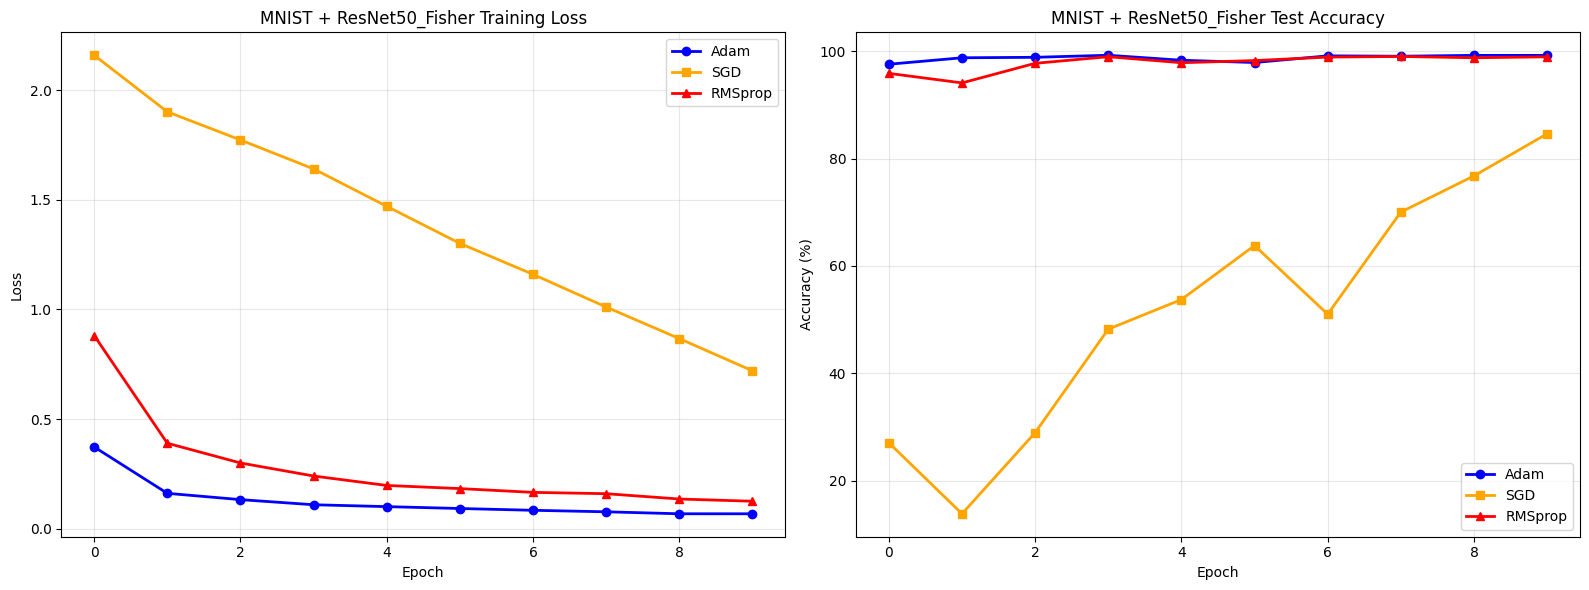

In [ ]:

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset parameters
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

K_PROBES = 4
EPSILON = 0.1

# Device setup for CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

class MNISTClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        # ResNet50 backbone
        resnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=False)
        self.intro = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool
        )
        self.layer1 = resnet_model.layer1
        self.layer2 = resnet_model.layer2
        self.layer3 = resnet_model.layer3
        self.layer4 = resnet_model.layer4
        self.averagepool = resnet_model.avgpool

        # Classification head (2048 + O0/O1/O2 + 4 fisher terms = 2055)
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 3 + 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        energy = x.mean()
        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True
        )[0]

        grads_flat = grads.view(grads.size(0), -1)
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def compute_local_fisher(self, x):
        scores = self.compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)

        x_resized = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        with torch.set_grad_enabled(True):
            if not x_resized.requires_grad:
                x_resized.requires_grad_(True)

            O0 = self.compute_local_fisher(x_resized)

            perturbation = torch.randn_like(x_resized) * self.epsilon
            x_pos = x_resized + perturbation
            x_neg = x_resized - perturbation

            I_pos = self.compute_local_fisher(x_pos)
            I_neg = self.compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x_resized)

        h = self.layer1(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer1 = self.compute_local_fisher(h)

        h = self.layer2(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer2 = self.compute_local_fisher(h)

        h = self.layer3(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer3 = self.compute_local_fisher(h)

        h = self.layer4(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer4 = self.compute_local_fisher(h)

        h_pooled = self.averagepool(h)
        h_flat = h_pooled.flatten(1)

        fish_concat = torch.cat([fish_layer1, fish_layer2, fish_layer3, fish_layer4], dim=1)
        features = torch.cat([h_flat, O0, O1, O2, fish_concat], dim=1)

        logits = self.classifier(features)
        return logits

def run_experiment(model, opt):
    model = model.to(device)
    optimizer = opt
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet50_fisher_adam, test_accuracies_resnet50_fisher_adam = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet50_fisher_sgd, test_accuracies_resnet50_fisher_sgd = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet50_fisher_rmsprop, test_accuracies_resnet50_fisher_rmsprop = run_experiment(model, opt)

epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet50_fisher_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet50_fisher_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet50_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet50_fisher_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet50_fisher_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet50_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet50_Fisher Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet50_Fisher Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet50_fisher_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet50_fisher_training.png'")
plt.show()

In [ ]:

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset parameters
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

K_PROBES = 4
EPSILON = 0.1

# Device setup for CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

class MNISTClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)  # 2D probe directions
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        # ResNet101 backbone
        resnet_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet101', pretrained=False)
        self.intro = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool
        )
        self.layer1 = resnet_model.layer1
        self.layer2 = resnet_model.layer2
        self.layer3 = resnet_model.layer3
        self.layer4 = resnet_model.layer4
        self.averagepool = resnet_model.avgpool

        # Classification head (2048 + O0/O1/O2 + 4 fisher terms = 2055)
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 3 + 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        energy = x.mean()
        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True
        )[0]

        grads_flat = grads.view(grads.size(0), -1)
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def compute_local_fisher(self, x):
        scores = self.compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)

        x_resized = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)

        with torch.set_grad_enabled(True):
            if not x_resized.requires_grad:
                x_resized.requires_grad_(True)

            O0 = self.compute_local_fisher(x_resized)

            perturbation = torch.randn_like(x_resized) * self.epsilon
            x_pos = x_resized + perturbation
            x_neg = x_resized - perturbation

            I_pos = self.compute_local_fisher(x_pos)
            I_neg = self.compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        h = self.intro(x_resized)

        h = self.layer1(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer1 = self.compute_local_fisher(h)

        h = self.layer2(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer2 = self.compute_local_fisher(h)

        h = self.layer3(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer3 = self.compute_local_fisher(h)

        h = self.layer4(h)
        with torch.set_grad_enabled(True):
            if not h.requires_grad:
                h.requires_grad_(True)
            fish_layer4 = self.compute_local_fisher(h)

        h_pooled = self.averagepool(h)
        h_flat = h_pooled.flatten(1)

        fish_concat = torch.cat([fish_layer1, fish_layer2, fish_layer3, fish_layer4], dim=1)
        features = torch.cat([h_flat, O0, O1, O2, fish_concat], dim=1)

        logits = self.classifier(features)
        return logits

def run_experiment(model, opt):
    model = model.to(device)
    optimizer = opt
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet101_fisher_adam, test_accuracies_resnet101_fisher_adam = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet101_fisher_sgd, test_accuracies_resnet101_fisher_sgd = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet101_fisher_rmsprop, test_accuracies_resnet101_fisher_rmsprop = run_experiment(model, opt)

epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet101_fisher_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet101_fisher_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet101_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet101_fisher_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet101_fisher_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet101_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet101_Fisher Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet101_Fisher Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet101_fisher_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet101_fisher_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000


Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Using device: cuda
Train samples: 60000, Test samples: 10000


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3226
Epoch 0, Batch 100/938: Loss=1.0338
Epoch 0, Batch 200/938: Loss=0.7888
Epoch 0, Batch 300/938: Loss=0.4324
Epoch 0, Batch 400/938: Loss=0.4379
Epoch 0, Batch 500/938: Loss=0.3890
Epoch 0, Batch 600/938: Loss=0.5625
Epoch 0, Batch 700/938: Loss=0.5830
Epoch 0, Batch 800/938: Loss=0.3447
Epoch 0, Batch 900/938: Loss=0.3217
Epoch 0 | Train Loss: 0.6383 | Test Accuracy: 96.58%
Epoch 1, Batch 0/938: Loss=0.3128
Epoch 1, Batch 100/938: Loss=0.2507
Epoch 1, Batch 200/938: Loss=0.2027
Epoch 1, Batch 300/938: Loss=0.3356
Epoch 1, Batch 400/938: Loss=0.3675
Epoch 1, Batch 500/938: Loss=0.1056
Epoch 1, Batch 600/938: Loss=0.2811
Epoch 1, Batch 700/938: Loss=0.2377
Epoch 1, Batch 800/938: Loss=0.2691
Epoch 1, Batch 900/938: Loss=0.2216
Epoch 1 | Train Loss: 0.3323 | Test Accuracy: 98.15%
Epoch 2, Batch 0/938: Loss=0.3084
Epoch 2, Batch 100/938: Loss=0.2170
Epoch 2, Batch 200/938: Loss=0.2995
Epoch 2, Batch 300/938: Loss=0.3019
Epoch 2, 

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3154
Epoch 0, Batch 100/938: Loss=2.3085


KeyboardInterrupt: 

In [ ]:

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

# Download and prepare MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

print("Downloading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Download ResNet50 (not pretrained)
print("Downloading ResNet50 model...")
base_resnet50 = models.resnet50(weights=None)

# Modify first layer to accept 1-channel input (MNIST is grayscale)
base_resnet50.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify output layer for 10 classes
num_ftrs = base_resnet50.fc.in_features
base_resnet50.fc = nn.Linear(num_ftrs, 10)

def make_resnet50():
    return copy.deepcopy(base_resnet50)

def run_experiment(model, optimizer):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    print(f"Starting Training for {EPOCHS} epochs...")
    train_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            
            if batch_idx % 150 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print("\nTraining Complete!")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = make_resnet50()
optimizer = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet50_baseline_adam, test_accuracies_resnet50_baseline_adam = run_experiment(model, optimizer)

model = make_resnet50()
optimizer = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet50_baseline_sgd, test_accuracies_resnet50_baseline_sgd = run_experiment(model, optimizer)

model = make_resnet50()
optimizer = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet50_baseline_rmsprop, test_accuracies_resnet50_baseline_rmsprop = run_experiment(model, optimizer)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet50_baseline_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet50_baseline_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet50_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet50_baseline_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet50_baseline_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet50_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet50_baseline Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet50_baseline Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet50_baseline_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet50_baseline_training.png'")
plt.show()


In [ ]:


import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

# Download and prepare MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

print("Downloading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Download ResNet101 (not pretrained)
print("Downloading ResNet101 model...")
base_resnet101 = models.resnet101(weights=None)

# Modify first layer to accept 1-channel input (MNIST is grayscale)
base_resnet101.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify output layer for 10 classes
num_ftrs = base_resnet101.fc.in_features
base_resnet101.fc = nn.Linear(num_ftrs, 10)

def make_resnet101():
    return copy.deepcopy(base_resnet101)

def run_experiment(model, optimizer):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    print(f"Starting Training for {EPOCHS} epochs...")
    train_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            
            if batch_idx % 150 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print("\nTraining Complete!")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = make_resnet101()
optimizer = optim.Adam(model.parameters(), lr=LR)
train_losses_resnet101_baseline_adam, test_accuracies_resnet101_baseline_adam = run_experiment(model, optimizer)

model = make_resnet101()
optimizer = optim.SGD(model.parameters(), lr=LR)
train_losses_resnet101_baseline_sgd, test_accuracies_resnet101_baseline_sgd = run_experiment(model, optimizer)

model = make_resnet101()
optimizer = optim.RMSprop(model.parameters(), lr=LR)
train_losses_resnet101_baseline_rmsprop, test_accuracies_resnet101_baseline_rmsprop = run_experiment(model, optimizer)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_resnet101_baseline_adam, 'Adam', 'o', 'blue'),
    (train_losses_resnet101_baseline_sgd, 'SGD', 's', 'orange'),
    (train_losses_resnet101_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_resnet101_baseline_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_resnet101_baseline_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_resnet101_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ResNet101_baseline Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ResNet101_baseline Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_resnet101_baseline_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_resnet101_baseline_training.png'")
plt.show()


In [8]:

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dataset parameters
NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

K_PROBES = 4
EPSILON = 0.1

# Device setup for CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
 ])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

class MNISTClassifier(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()
        self.epsilon = epsilon
        self.k_probes = k_probes
        self.num_classes = num_classes

        v = torch.randn(k_probes, 2)
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        self.vit = torchvision.models.vit_b_16(weights=None)
        self.vit.conv_proj = nn.Conv2d(1, 768, kernel_size=16, stride=16, padding=0, bias=False)

        self.classifier = nn.Sequential(
            nn.Linear(768 + 3 + 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def compute_score(self, x):
        if not x.requires_grad:
            x.requires_grad_(True)

        energy = x.mean()
        grads = torch.autograd.grad(
            outputs=energy,
            inputs=x,
            create_graph=True,
            retain_graph=True
        )[0]

        grads_flat = grads.view(grads.size(0), -1)
        if grads_flat.size(1) >= 2:
            grads_2d = grads_flat[:, :2]
        else:
            grads_2d = grads_flat

        scores = -torch.matmul(grads_2d, self.probes.T)
        return scores

    def compute_local_fisher(self, x):
        scores = self.compute_score(x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            O0 = self.compute_local_fisher(x)

            perturbation = torch.randn_like(x) * self.epsilon
            I_pos = self.compute_local_fisher(x + perturbation)
            I_neg = self.compute_local_fisher(x - perturbation)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        n = x.shape[0]
        h = self.vit._process_input(x)
        batch_class_token = self.vit.class_token.expand(n, -1, -1)
        h = torch.cat([batch_class_token, h], dim=1)
        h = h + self.vit.encoder.pos_embedding
        h = self.vit.encoder.dropout(h)

        fisher_terms = []
        for layer_idx, layer in enumerate(self.vit.encoder.layers):
            h = layer(h)
            if layer_idx in (2, 5, 8, 11):
                with torch.set_grad_enabled(True):
                    if not h.requires_grad:
                        h.requires_grad_(True)
                    fisher_terms.append(self.compute_local_fisher(h))

        h = self.vit.encoder.ln(h)
        cls_feature = h[:, 0]
        fish_concat = torch.cat(fisher_terms, dim=1)
        features = torch.cat([cls_feature, O0, O1, O2, fish_concat], dim=1)

        logits = self.classifier(features)
        return logits

def run_experiment(model, opt):
    model = model.to(device)
    optimizer = opt
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    test_accuracies = []

    print("Starting MNIST Training...")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.Adam(model.parameters(), lr=LR)
train_losses_vit_fisher_adam, test_accuracies_vit_fisher_adam = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.SGD(model.parameters(), lr=LR)
train_losses_vit_fisher_sgd, test_accuracies_vit_fisher_sgd = run_experiment(model, opt)

model = MNISTClassifier(NUM_CLASSES, K_PROBES, EPSILON)
opt = optim.RMSprop(model.parameters(), lr=LR)
train_losses_vit_fisher_rmsprop, test_accuracies_vit_fisher_rmsprop = run_experiment(model, opt)

epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_vit_fisher_adam, 'Adam', 'o', 'blue'),
    (train_losses_vit_fisher_sgd, 'SGD', 's', 'orange'),
    (train_losses_vit_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_vit_fisher_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_vit_fisher_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_vit_fisher_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ViT_b_16_Fisher Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ViT_b_16_Fisher Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_vit_b_16_fisher_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_vit_b_16_fisher_training.png'")
plt.show()

Using device: cuda
Train samples: 60000, Test samples: 10000
Starting MNIST Training...
Epoch 0, Batch 0/938: Loss=2.3648
Epoch 0, Batch 100/938: Loss=2.3011
Epoch 0, Batch 200/938: Loss=2.2998
Epoch 0, Batch 300/938: Loss=2.2952
Epoch 0, Batch 400/938: Loss=2.3024
Epoch 0, Batch 500/938: Loss=2.3011
Epoch 0, Batch 600/938: Loss=2.2990
Epoch 0, Batch 700/938: Loss=2.3019
Epoch 0, Batch 800/938: Loss=2.2960
Epoch 0, Batch 900/938: Loss=2.3059
Epoch 0 | Train Loss: 2.3032 | Test Accuracy: 11.35%
Epoch 1, Batch 0/938: Loss=2.2952
Epoch 1, Batch 100/938: Loss=2.2953
Epoch 1, Batch 200/938: Loss=2.3049


KeyboardInterrupt: 

In [6]:


import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

# Download and prepare MNIST dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

print("Downloading MNIST dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Download ViT (not pretrained)
print("Downloading ViT model...")
base_vit = models.vit_b_16(weights=None)

# Modify first layer to accept 1-channel input (MNIST is grayscale)
base_vit.conv_proj = nn.Conv2d(1, 768, kernel_size=16, stride=16, padding=0, bias=False)

# Modify output layer for 10 classes
num_ftrs = base_vit.heads.head.in_features
base_vit.heads.head = nn.Linear(num_ftrs, 10)

def make_vit():
    return copy.deepcopy(base_vit)

def run_experiment(model, optimizer):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    print(f"Starting Training for {EPOCHS} epochs...")
    train_losses = []
    test_accuracies = []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            
            if batch_idx % 150 == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        
        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    print("\nTraining Complete!")
    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies

# For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
model = make_vit()
optimizer = optim.Adam(model.parameters(), lr=LR)
train_losses_vit_baseline_adam, test_accuracies_vit_baseline_adam = run_experiment(model, optimizer)

model = make_vit()
optimizer = optim.SGD(model.parameters(), lr=LR)
train_losses_vit_baseline_sgd, test_accuracies_vit_baseline_sgd = run_experiment(model, optimizer)

model = make_vit()
optimizer = optim.RMSprop(model.parameters(), lr=LR)
train_losses_vit_baseline_rmsprop, test_accuracies_vit_baseline_rmsprop = run_experiment(model, optimizer)

# Plot training results
epochs = list(range(EPOCHS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for loss, label, marker, color in [
    (train_losses_vit_baseline_adam, 'Adam', 'o', 'blue'),
    (train_losses_vit_baseline_sgd, 'SGD', 's', 'orange'),
    (train_losses_vit_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

for acc, label, marker, color in [
    (test_accuracies_vit_baseline_adam, 'Adam', 'o', 'blue'),
    (test_accuracies_vit_baseline_sgd, 'SGD', 's', 'orange'),
    (test_accuracies_vit_baseline_rmsprop, 'RMSprop', '^', 'red'),
]:
    ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MNIST + ViT_b_16_baseline Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MNIST + ViT_b_16_baseline Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mnist_vit_b_16_baseline_training.png', dpi=150, bbox_inches='tight')
print("Training plots saved as 'mnist_vit_b_16_baseline_training.png'")
plt.show()


Using device: cuda
Train samples: 60000, Test samples: 10000
Starting Training for 10 epochs...
Epoch 0, Batch 0/938: Loss=2.5376
Epoch 0, Batch 150/938: Loss=2.3523
Epoch 0, Batch 300/938: Loss=2.1152
Epoch 0, Batch 450/938: Loss=2.1106
Epoch 0, Batch 600/938: Loss=1.8994
Epoch 0, Batch 750/938: Loss=2.1684
Epoch 0, Batch 900/938: Loss=1.9834
Epoch 0 | Train Loss: 2.1411 | Test Accuracy: 22.71%
Epoch 1, Batch 0/938: Loss=2.0601
Epoch 1, Batch 150/938: Loss=2.0016


KeyboardInterrupt: 

In [1]:
import pandas as pd

rows = []

g = globals()
loss_keys = sorted([k for k in g.keys() if k.startswith('train_losses_')])

for loss_key in loss_keys:
    suffix = loss_key.replace('train_losses_', '', 1)
    acc_key = f'test_accuracies_{suffix}'

    losses = g.get(loss_key)
    accuracies = g.get(acc_key)

    if losses is None or accuracies is None:
        continue

    n_epochs = min(len(losses), len(accuracies))
    for epoch in range(n_epochs):
        rows.append({
            'experiment': suffix,
            'epoch': epoch,
            'train_loss': float(losses[epoch]),
            'test_accuracy': float(accuracies[epoch])
        })

if not rows:
    raise RuntimeError(
        "No training outputs found. Run Cells 1–8 first so train_losses_* and test_accuracies_* variables exist."
    )

output_df = pd.DataFrame(rows).sort_values(['experiment', 'epoch']).reset_index(drop=True)
output_path = 'test1_copycopy_output.csv'
output_df.to_csv(output_path, index=False)

print(f"Saved {len(output_df)} rows to {output_path}")
print(output_df.head())

RuntimeError: No training outputs found. Run Cells 1–8 first so train_losses_* and test_accuracies_* variables exist.